In [28]:
#Imports and Environments setup

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import kurtosis, skew
from sklearn.ensemble import IsolationForest

In [30]:
#Load Dataset 

In [31]:
df_train = pd.read_csv("dataset1.csv")
df_test = pd.read_csv("dataset2.csv")

In [32]:
# Data Structure Inspection

In [33]:
df_train.shape
df_train.columns
df_train.head()

,condition,vibration_0,vibration_1,vibration_2,vibration_3,vibration_4,vibration_5,vibration_6,vibration_7,vibration_8,...,vibration_477,vibration_478,vibration_479,vibration_480,vibration_481,vibration_482,vibration_483,vibration_484,vibration_485,label
0,normal,0.024836,0.111913,0.268353,0.425919,0.446902,0.549247,0.734310,0.778831,0.791603,...,0.278103,0.529282,0.538796,0.577060,0.628049,0.678297,0.840837,0.853121,0.867475,6
1,normal,-0.032329,0.016103,0.224372,0.253241,0.276873,0.418014,0.412934,0.429033,0.608956,...,0.904792,0.828028,0.863587,0.712925,0.788273,0.644256,0.519576,0.539455,0.438305,6
2,normal,0.042032,-0.011598,0.019749,-0.031413,0.061426,-0.016212,0.046681,0.184736,0.206779,...,-0.571009,-0.573756,-0.520952,-0.610621,-0.508896,-0.626743,-0.758805,-0.648551,-0.682308,6
3,normal,0.064488,0.075939,0.077562,0.065323,0.157914,0.167365,0.222016,0.321173,0.415419,...,0.894573,0.991867,1.010272,1.047118,1.001895,1.014782,0.980393,1.012239,0.978645,6
4,normal,0.031079,0.068739,0.192628,0.257540,0.398561,0.420336,0.411679,0.637037,0.597890,...,-0.669731,-0.796681,-0.838401,-0.957425,-0.893086,-0.921122,-0.976522,-0.933464,-1.015111,6


In [34]:
#Track Section Assignment

In [35]:
# Define simulated track sections (for demo/testing)
NUM_SECTIONS = 4
SECTIONS = [f"KM_{i}" for i in range(1, NUM_SECTIONS + 1)]

print("Simulated Track Sections:", SECTIONS)

Simulated Track Sections: ['KM_1', 'KM_2', 'KM_3', 'KM_4']


In [36]:
# Select Vibration Columns

In [37]:
vibration_cols = [c for c in df_train.columns if c.startswith("vibration_")]

In [38]:
# DataType Cleaning

In [39]:
df_train[vibration_cols] = df_train[vibration_cols].apply(
    pd.to_numeric, errors="coerce"
)
df_test[vibration_cols] = df_test[vibration_cols].apply(
    pd.to_numeric, errors="coerce"
)

df_train[vibration_cols] = df_train[vibration_cols].fillna(
    df_train[vibration_cols].mean()
)
df_test[vibration_cols] = df_test[vibration_cols].fillna(
    df_train[vibration_cols].mean()
)

In [40]:
#Feature Extraction 

In [68]:
def extract_features(row):
    row = np.asarray(row, dtype=np.float64)   # FORCE numeric
    row = np.nan_to_num(row, nan=np.mean(row))

    return [
        np.mean(row),
        np.std(row),
        np.max(row) - np.min(row),
        np.sqrt(np.mean(row ** 2)),
        kurtosis(row),
        skew(row)
    ]


In [50]:
#Feature Matrix Creation

In [69]:
X_train = np.array([
    extract_features(df_train.loc[i, vibration_cols].values)
    for i in df_train.index
])

In [70]:
# TEMPORAL PERSISTENCE SCORING

In [71]:
WINDOW = 5  # last 5 vibration windows

persistence_scores = []

for i in range(len(scores)):
    start = max(0, i - WINDOW + 1)
    persistence_scores.append(np.mean(scores[start:i+1]))

persistence_scores = np.array(persistence_scores)


In [ ]:
# EXPLAINABILITY LAYER

In [73]:
explanations = []

RMS_THRESHOLD = np.percentile(
    [extract_features(df_test.loc[i, vibration_cols].values)[3] 
     for i in df_test.index], 95
)

for i in range(len(df_test)):
    reasons = []
    features = extract_features(df_test.loc[i, vibration_cols].values)

    if features[3] > RMS_THRESHOLD:
        reasons.append("High energy vibration (impact-like)")

    if features[4] > 5:
        reasons.append("High kurtosis (impulsive signal)")

    explanations.append(reasons)

In [ ]:
# RISK LEVEL ASSIGNMENT

In [74]:
risk_levels = []

for score in persistence_scores:
    if score > np.percentile(persistence_scores, 95):
        risk_levels.append("HIGH")
    elif score > np.percentile(persistence_scores, 85):
        risk_levels.append("MEDIUM")
    else:
        risk_levels.append("LOW")


In [75]:
# Now the raw vibration is ML Ready

In [76]:
# Train Isolation Forest

In [77]:
iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

iso_forest.fit(X_train)

,n_estimators,300
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [78]:
# Test & Score Anomalies

In [79]:
X_test = np.array([
    extract_features(df_test.loc[i, vibration_cols].values)
    for i in df_test.index
])

scores = -iso_forest.score_samples(X_test)

In [80]:
#Visualization

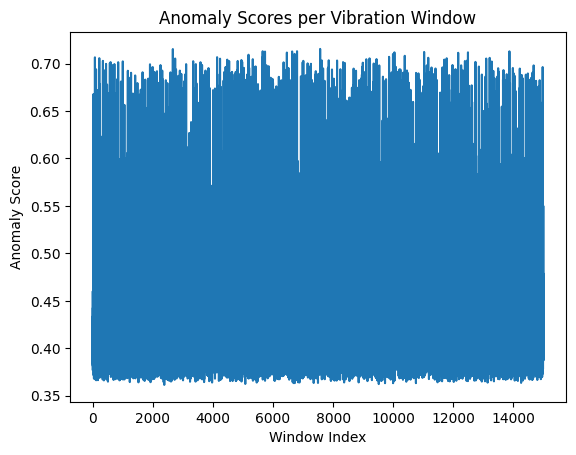

In [81]:
plt.figure()
plt.plot(scores)
plt.title("Anomaly Scores per Vibration Window")
plt.xlabel("Window Index")
plt.ylabel("Anomaly Score")
plt.show()

In [82]:
#FURTHER ADD ONS for testing and understanding 

In [83]:
# testing

In [84]:
print("Number of trees:", len(iso_forest.estimators_))
print("Feature importance not applicable (unsupervised model)")

Number of trees: 300
Feature importance not applicable (unsupervised model)


In [85]:
#Synthetic Tampering

In [86]:
signal_example = df_test[vibration_cols].iloc[0].values.copy()

# Inject artificial tampering spikes
signal_example[100:120] += 5

tampered_features = extract_features(signal_example)

normal_score = -iso_forest.score_samples([X_test[0]])[0]
tampered_score = -iso_forest.score_samples([tampered_features])[0]

print("Normal score:", normal_score)
print("Tampered score:", tampered_score)

Normal score: 0.37777692451944717
Tampered score: 0.7423761618844475


In [87]:
#Threshold Logic

In [88]:
threshold = np.percentile(scores, 95)

alerts = scores > threshold
print("Number of high-risk alerts:", alerts.sum())

Number of high-risk alerts: 750


In [89]:
# FUSION-READY SENSOR OUTPUT

In [90]:
sensor_events = []

for i in range(len(scores)):
    event = {
        "window_id": i,
        "anomaly_score": float(scores[i]),
        "persistence_score": float(persistence_scores[i]),
        "risk_level": risk_levels[i],
        "explanation": explanations[i]
    }
    sensor_events.append(event)

sensor_events[:3]

[{'window_id': 0,
  'anomaly_score': 0.37777692451944717,
  'persistence_score': 0.37777692451944717,
  'risk_level': 'LOW',
  'explanation': []},
 {'window_id': 1,
  'anomaly_score': 0.41869286154236085,
  'persistence_score': 0.398234893030904,
  'risk_level': 'LOW',
  'explanation': []},
 {'window_id': 2,
  'anomaly_score': 0.4334183223191544,
  'persistence_score': 0.4099627027936541,
  'risk_level': 'LOW',
  'explanation': []}]